In [1]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from models.unet import UNet

model_path = "ckpt/unet_rgb.pth"
test_image_dir = "./SUIM/TEST/images"
test_mask_dir = "./SUIM/TEST/masks"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(input_channels=3, num_classes=8).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

input_size = (320, 240)  # (width, height)
transform_img = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(input_size),
    transforms.ToTensor()
])

## Testing Functions

**rgb_to_class() function** converts colored segmentation masks into numerical class masks that the model can interpret. It takes the RGB image where each pixel is colored according to its object class, then creates a grayscale mask where each pixel contains the corresponding class number instead of the color.

**decode_segmap() function** takes the model's numerical predictions and converts them back into colored images. This lets you see the segmentation results as colored masks.

In [2]:

COLOR2CLASS = {
    (0, 0, 0): 0,
    (0, 0, 255): 1,
    (0, 255, 0): 2,
    (0, 255, 255): 3,
    (255, 0, 0): 4,
    (255, 0, 255): 5,
    (255, 255, 0): 6,
    (255, 255, 255): 7
}
CLASS2COLOR = {v: k for k, v in COLOR2CLASS.items()}

def rgb_to_class(mask_rgb): #RGB to class
    h, w, _ = mask_rgb.shape
    class_mask = np.zeros((h, w), dtype=np.uint8)
    for color, class_idx in COLOR2CLASS.items():
        matches = np.all(mask_rgb == color, axis=-1)
        class_mask[matches] = class_idx
    return class_mask

def decode_segmap(segmap):#class to RGB
    h, w = segmap.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for class_idx, color in CLASS2COLOR.items():
        color_mask[segmap == class_idx] = color
    return color_mask

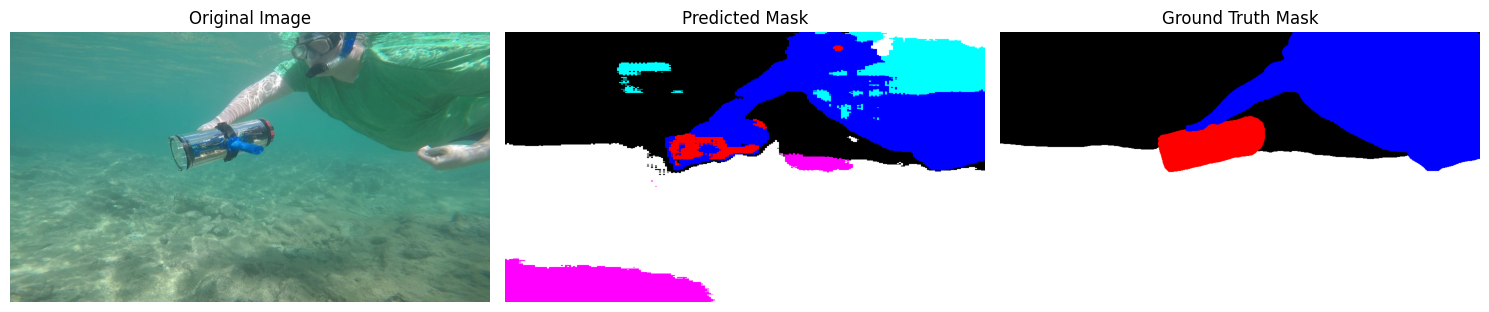

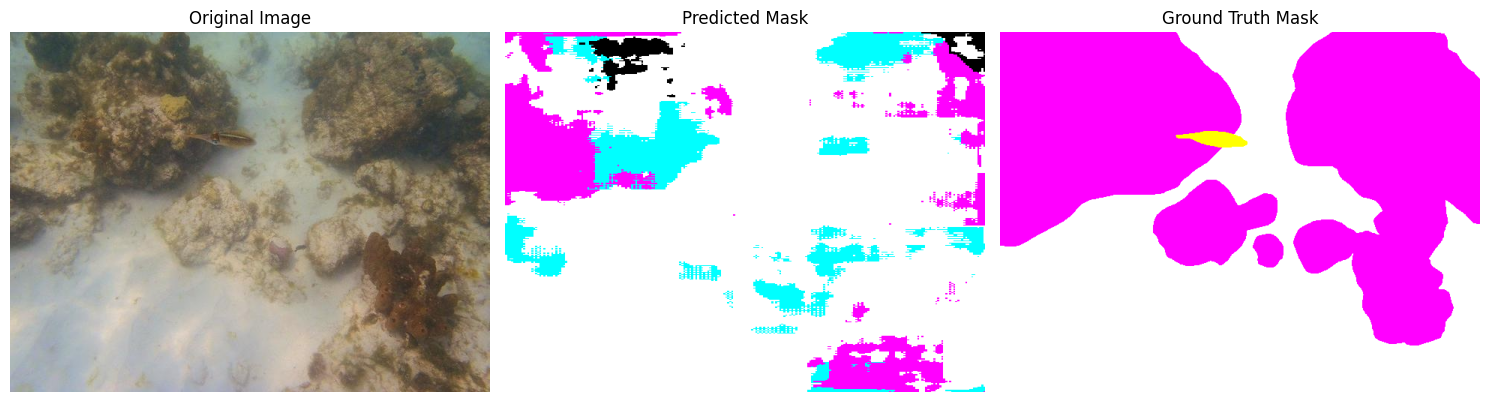

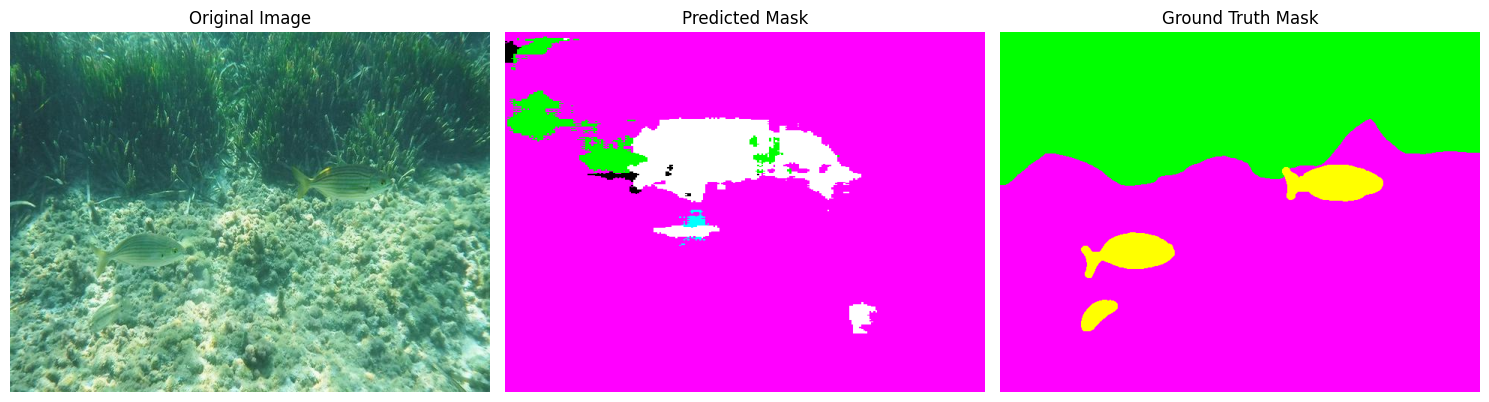

In [3]:
image_names = sorted([f for f in os.listdir(test_image_dir) if f.endswith(".jpg")])[:3]
mask_names = sorted([f for f in os.listdir(test_mask_dir) if f.endswith(".bmp")])[:3]

for i in range(3):
    #Load and preprocess image
    img_path = os.path.join(test_image_dir, image_names[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_size = (img.shape[1], img.shape[0])  # (width, height)

    #Load and preprocess mask
    mask_path = os.path.join(test_mask_dir, mask_names[i])
    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    #Resize image
    img_resized = cv2.resize(img, input_size)
    img_input = transform_img(img_resized).unsqueeze(0).to(device)

    #Predict mask
    with torch.no_grad():
        pred = model(img_input)  # Shape: (1, num_classes, H, W)
        pred_mask = torch.argmax(pred.squeeze(), dim=0).cpu().numpy()
        pred_mask_resized = cv2.resize(
            pred_mask.astype(np.uint8),
            original_size,
            interpolation=cv2.INTER_NEAREST
        )

    #Convert ground truth mask to class indices and then color
    gt_class_mask = rgb_to_class(mask)
    gt_color_mask = decode_segmap(gt_class_mask)

    # Convert predicted class mask to color
    pred_color_mask = decode_segmap(pred_mask_resized)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img)
    axs[0].set_title("Original Image")
    axs[1].imshow(pred_color_mask)
    axs[1].set_title("Predicted Mask")
    axs[2].imshow(gt_color_mask)
    axs[2].set_title("Ground Truth Mask")

    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
